<a href="https://colab.research.google.com/github/TMDaniels75/HF-Data-Analytics-Program-/blob/main/Updated_Capstone_Project_Data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import glob

In [4]:
df=pd.read_csv("https://raw.githubusercontent.com/TMDaniels75/HF-Data-Analytics-Program-/refs/heads/main/Shooting_Victims_(2006-Present)_20260518.csv")

In [5]:
df.shape

(28912, 6)

In [6]:
df=pd.read_csv("https://raw.githubusercontent.com/TMDaniels75/HF-Data-Analytics-Program-/refs/heads/main/Shootings_(2006-Present)_20260518.csv")

In [7]:
df.shape

(24127, 13)

In [8]:
Victims= pd.read_csv("https://raw.githubusercontent.com/TMDaniels75/HF-Data-Analytics-Program-/refs/heads/main/Shooting_Victims_(2006-Present)_20260518.csv")
Shootings= pd.read_csv("https://raw.githubusercontent.com/TMDaniels75/HF-Data-Analytics-Program-/refs/heads/main/Shootings_(2006-Present)_20260518.csv")
#

In [9]:
Shootings.columns = Shootings.columns.str.strip()
Victims.columns = Victims.columns.str.strip()

In [10]:
combined = pd.merge(
    Shootings,
    Victims,
    on='INCIDENT_KEY',
    how='outer'
)

In [11]:
combined.shape

(28912, 18)

In [12]:
combined.columns.tolist()

['INCIDENT_KEY',
 'OCCUR_DATE',
 'OCCUR_TIME',
 'BORO',
 'LOC_OF_OCCUR_DESC',
 'PRECINCT',
 'JURISDICTION_CODE',
 'LOC_CLASSFCTN_DESC',
 'LOCATION_DESC',
 'X_COORD_CD',
 'Y_COORD_CD',
 'Latitude',
 'Longitude',
 'VICTIM_ID',
 'VICTIM_AGE_GROUP',
 'VICTIM_SEX',
 'VICTIM_RACE',
 'STAT_MURDER_FLG']

In [13]:
combined.to_csv("combined_shootings_victims.csv", index=False)

In [14]:
combined = combined.dropna(subset=['BORO'])

In [15]:
borough_counts = combined['BORO'].value_counts()

borough_counts

,count
BORO,
BROOKLYN,11717
BRONX,8365
QUEENS,4310
MANHATTAN,3760
STATEN ISLAND,758


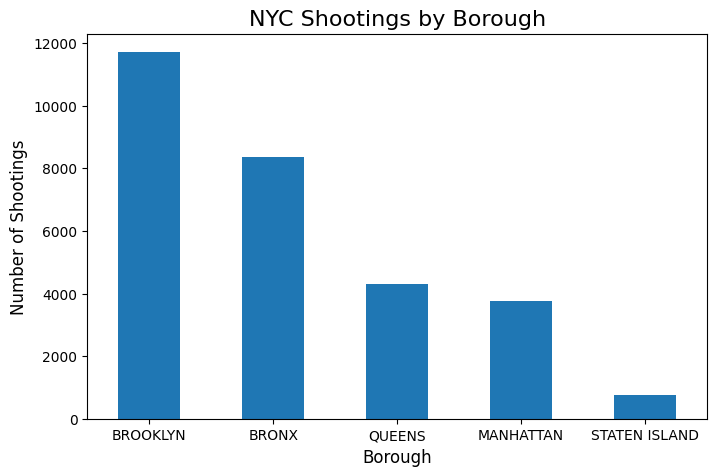

In [16]:
borough_counts.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("NYC Shootings by Borough", fontsize=16)

plt.xlabel("Borough", fontsize=12)

plt.ylabel("Number of Shootings", fontsize=12)

plt.xticks(rotation=0)

plt.show()

In [17]:
top_precincts = combined['PRECINCT'].value_counts().head(10)

top_precincts

,count
PRECINCT,
75.0,1656
73.0,1587
67.0,1329
44.0,1085
79.0,1061
47.0,1020
40.0,988
46.0,947
42.0,868


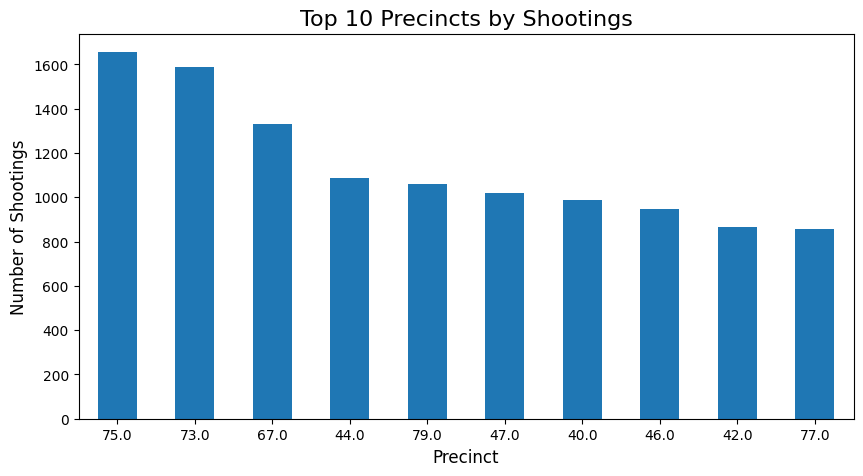

In [18]:
top_precincts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Precincts by Shootings", fontsize=16)

plt.xlabel("Precinct", fontsize=12)

plt.ylabel("Number of Shootings", fontsize=12)

plt.xticks(rotation=0)

plt.show()

In [20]:
combined['OCCUR_TIME'] = pd.to_datetime(
    combined['OCCUR_TIME'],
    format='%H:%M:%S'
)

In [21]:
combined['HOUR'] = combined['OCCUR_TIME'].dt.hour

In [22]:
hour_counts = combined['HOUR'].value_counts().sort_index()

hour_counts

,count
HOUR,
0,2331
1,2142
2,1885
3,1729
4,1524
5,754
6,398
7,251
8,266


In [23]:
combined['HOUR_LABEL'] = combined['OCCUR_TIME'].dt.strftime('%I %p')

In [24]:
hour_order = [
    '12 AM','01 AM','02 AM','03 AM','04 AM','05 AM',
    '06 AM','07 AM','08 AM','09 AM','10 AM','11 AM',
    '12 PM','01 PM','02 PM','03 PM','04 PM','05 PM',
    '06 PM','07 PM','08 PM','09 PM','10 PM','11 PM'
]

hour_counts = combined['HOUR_LABEL'].value_counts().reindex(hour_order)

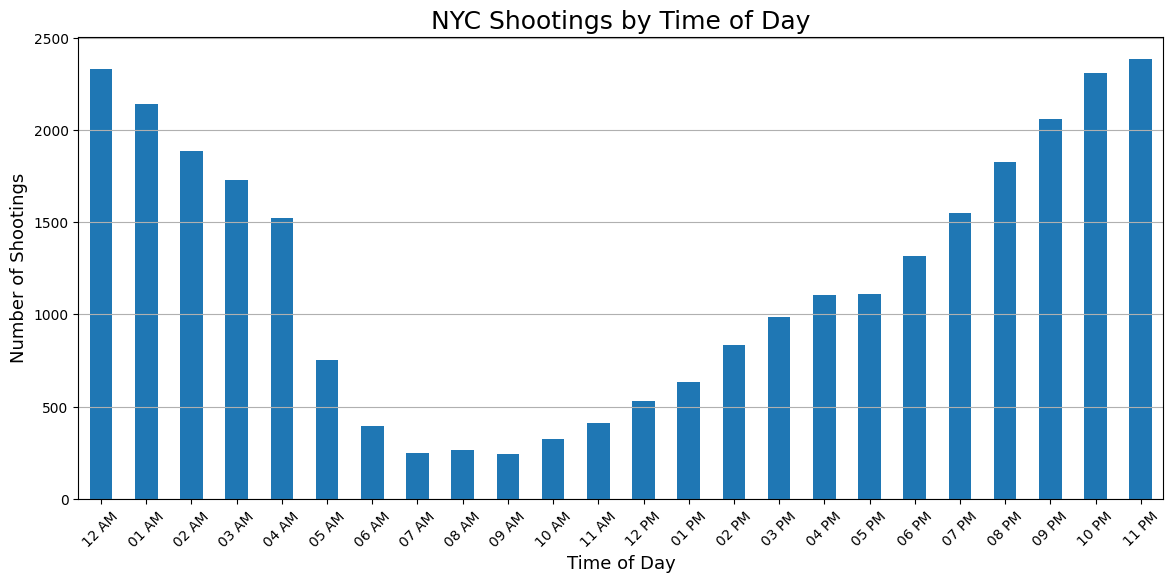

In [25]:
plt.figure(figsize=(14,6))

hour_counts.plot(kind='bar')

plt.title("NYC Shootings by Time of Day", fontsize=18)

plt.xlabel("Time of Day", fontsize=13)

plt.ylabel("Number of Shootings", fontsize=13)

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

In [26]:
combined['VICTIM_AGE_GROUP'].value_counts()

,count
VICTIM_AGE_GROUP,
25-44,13253
18-24,10428
<18,2989
45-64,1973
65+,209
UNKNOWN,57
1022,1


In [27]:
age_counts = combined[
    combined['VICTIM_AGE_GROUP'] != 'UNKNOWN'
]['VICTIM_AGE_GROUP'].value_counts()

In [28]:
age_order = ['<18', '18-24', '25-44', '45-64', '65+']

age_counts = age_counts.reindex(age_order)

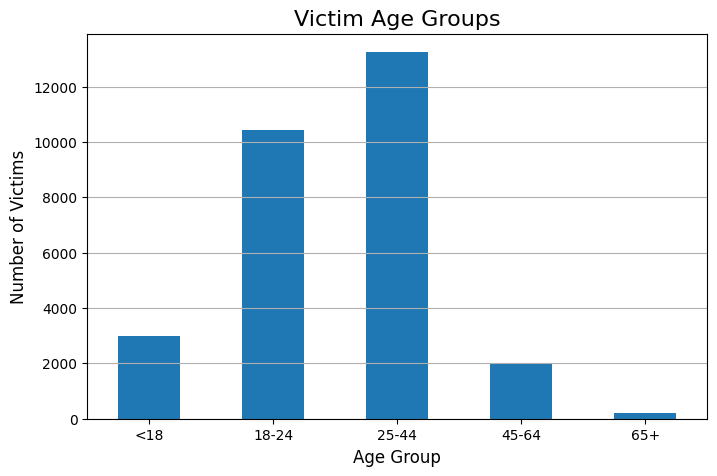

In [29]:
plt.figure(figsize=(8,5))

age_counts.plot(kind='bar')

plt.title("Victim Age Groups", fontsize=16)

plt.xlabel("Age Group", fontsize=12)

plt.ylabel("Number of Victims", fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()

In [34]:
sex_counts = combined['VICTIM_SEX'].value_counts()

sex_counts


,count
VICTIM_SEX,
MALE,26267
FEMALE,2632
UNKNOWN,10
INTERSEX,1


In [35]:
combined['VICTIM_SEX'].value_counts(dropna=False)

,count
VICTIM_SEX,
MALE,26267
FEMALE,2632
UNKNOWN,10
INTERSEX,1


In [36]:
clean_sex = combined[
    (combined['VICTIM_SEX'].notna()) &
    (combined['VICTIM_SEX'] != 'U') &
    (combined['VICTIM_SEX'] != 'UNKNOWN')
]

In [37]:
clean_sex['VICTIM_SEX'].value_counts(dropna=False)

,count
VICTIM_SEX,
MALE,26267
FEMALE,2632
INTERSEX,1


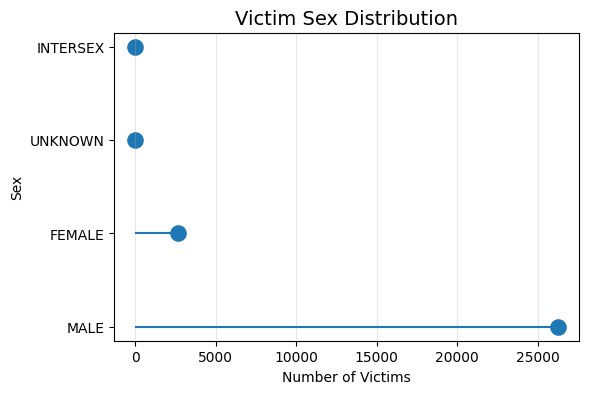

In [38]:
plt.figure(figsize=(6,4))

# draw horizontal stem lines
plt.hlines(
    y=sex_counts.index,
    xmin=0,
    xmax=sex_counts.values
)

# add dots at the end
plt.scatter(
    sex_counts.values,
    sex_counts.index,
    s=120
)

plt.title("Victim Sex Distribution", fontsize=14)

plt.xlabel("Number of Victims")

plt.ylabel("Sex")

plt.grid(axis='x', alpha=0.3)

plt.show()

In [39]:
clean_race = combined['VICTIM_RACE'].dropna()

race_counts = clean_race.value_counts()

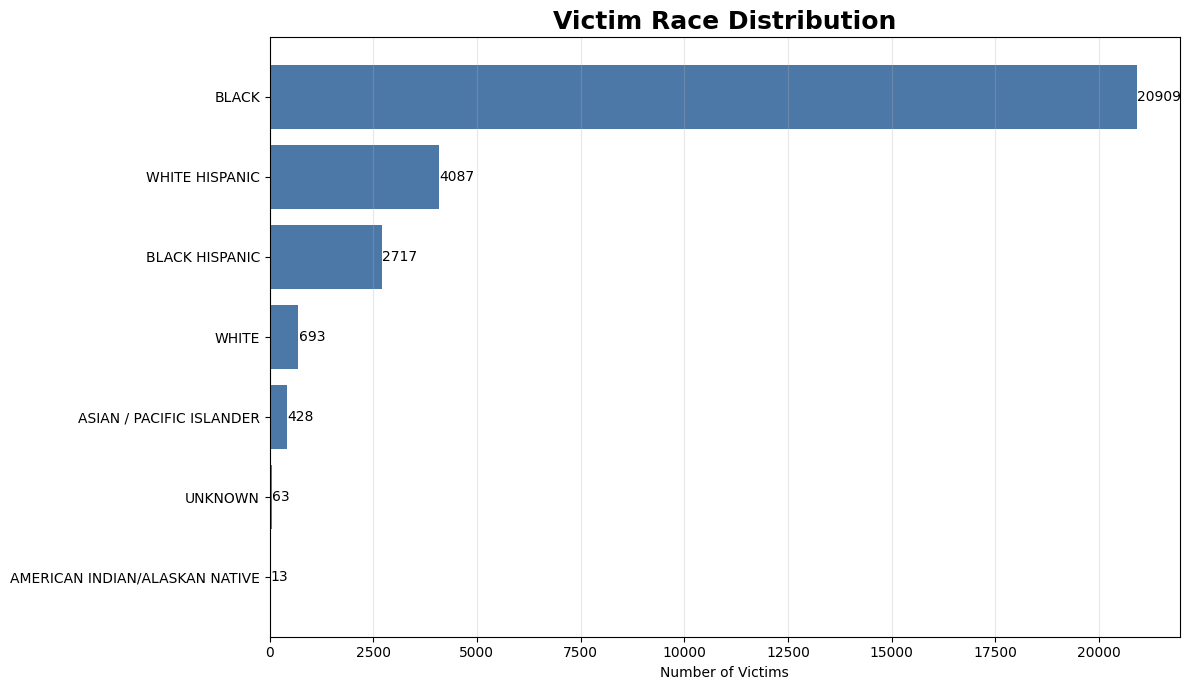

In [40]:
plt.figure(figsize=(12,7))

race_counts = race_counts.sort_values()

bars = plt.barh(
    race_counts.index,
    race_counts.values,
    color="#4C78A8"
)

plt.title("Victim Race Distribution", fontsize=18, fontweight='bold')

plt.xlabel("Number of Victims")

plt.grid(axis='x', alpha=0.3)

# labels
for bar in bars:
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va='center'
    )

plt.tight_layout()

plt.show()

In [41]:
combined['OCCUR_DATE'] = pd.to_datetime(combined['OCCUR_DATE'])

In [42]:
combined['YEAR'] = combined['OCCUR_DATE'].dt.year

In [43]:
year_counts = combined['YEAR'].value_counts().sort_index()

year_counts

,count
YEAR,
2006,1881
2007,1720
2008,1807
2009,1727
2010,1775
2011,1821
2012,1624
2013,1299
2014,1391


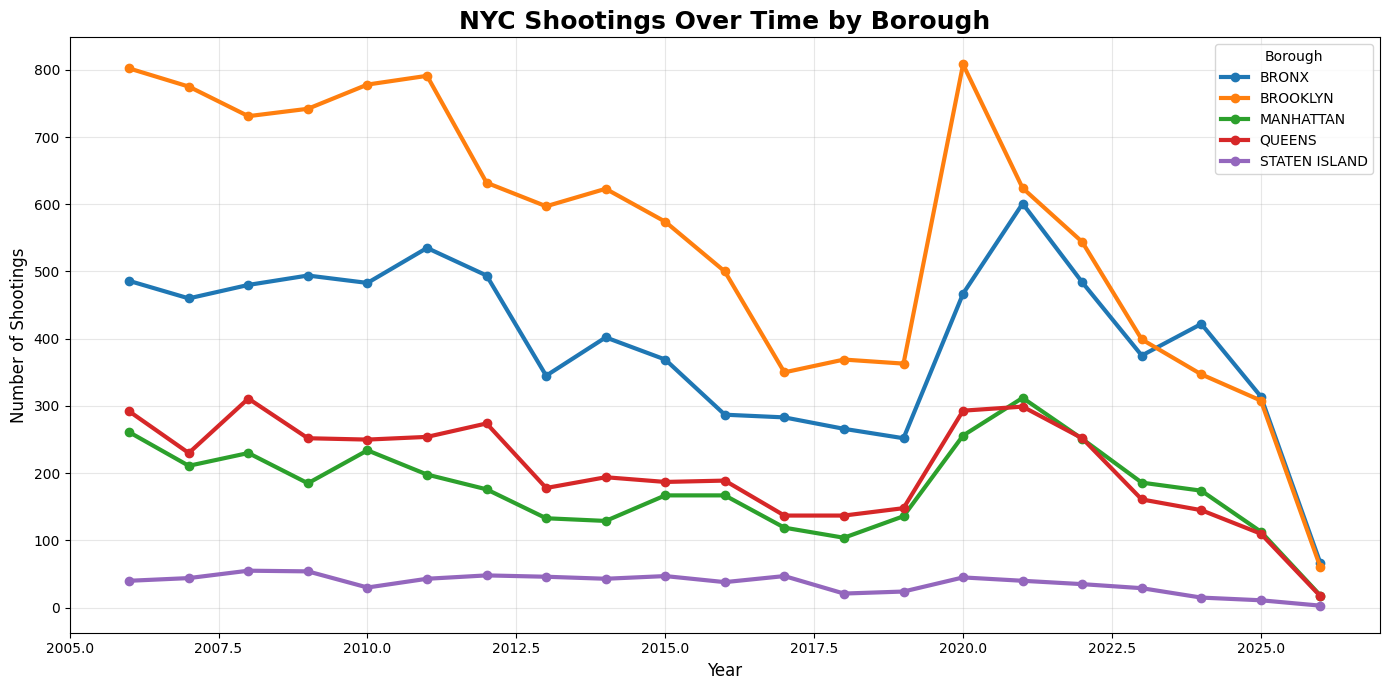

In [44]:
trend_data = pd.crosstab(
    combined['YEAR'],
    combined['BORO']
)

plt.figure(figsize=(14,7))

for col in trend_data.columns:
    plt.plot(
        trend_data.index,
        trend_data[col],
        marker='o',
        linewidth=3,
        label=col
    )

plt.title(
    "NYC Shootings Over Time by Borough",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Year", fontsize=12)

plt.ylabel("Number of Shootings", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(title="Borough")

plt.tight_layout()

plt.show()